In [ ]:
import os
import copy
import pickle
import re
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.functions import StepFunction
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.metrics import (concordance_index_censored, 
                            integrated_brier_score, 
                            cumulative_dynamic_auc)

In [ ]:
# 発症者の観察開始時年齢分布
case_df = pd.read_csv('./data/S720-S722/pid_S720-S722.csv')
summary_df = pd.read_csv('./data/patient_matching_data.csv')
print(len(summary_df))
summary_df["case"] = summary_df["kojin_id"].isin(case_df.kojin_id)
summary_df.head()

2388375


,kojin_id,sex_code,observation_start_age,observation_months,months_until_first_kenshin,kenshin_times,first_exam_date,case
0,9,2,40,75,48,1,2019-09-18,False
1,13,2,40,84,25,5,2017-03-08,False
2,23,2,65,59,7,1,2016-11-07,False
3,26,2,66,68,2,5,2016-06-06,False
4,28,2,66,92,0,4,2014-04-09,False


### Data check

In [ ]:
import duckdb

con = duckdb.connect()
tempath = "./data/original/receipt_diseases.csv"
query=f"""
WITH base AS (
    SELECT *
    FROM read_csv_auto('{tempath}')
),

dict AS (
    SELECT *
    FROM read_csv_auto('./data/original/m_icd10.csv')
),

-- 特定列だけ変換
transformed AS (
    SELECT
        b.*,
        d.icd10_sub_code AS icd10_mapped
    FROM base b
    LEFT JOIN dict d
    ON b.diseases_code = d.diseases_code
)

-- 欠損＆出現数集計
SELECT icd10_mapped,
    COUNT(*) AS total_rows
FROM transformed
GROUP BY icd10_mapped
ORDER BY total_rows DESC;
"""

df = con.execute(query).df()


In [ ]:
#df.sort_values("total_rows", ascending=True).to_csv("./data/whole_icd10_sub.csv", index=False)

In [ ]:
con = duckdb.connect()
tempath = "./data/original/receipt_diseases.csv"
query=f"""

WITH base AS (
    SELECT *
    FROM read_csv_auto('{tempath}')
),

dict AS (
    SELECT *
    FROM read_csv_auto('./data/m_icd10.csv')
),

-- ICDコード変換
transformed AS (
    SELECT
        b.kojin_id,
        d.icd10_sub_code AS icd10
    FROM base b
    LEFT JOIN dict d
    ON b.diseases_code = d.diseases_code
),

-- 全ID数
total_ids AS (
    SELECT COUNT(DISTINCT kojin_id) AS n_total
    FROM transformed
),

-- ICDを持つID数
icd_id_count AS (
    SELECT
        icd10,
        COUNT(DISTINCT kojin_id) AS n_ids
    FROM transformed
    WHERE icd10 IS NOT NULL
    GROUP BY icd10
)

-- 割合
SELECT
    i.icd10,
    i.n_ids,
    t.n_total,
    i.n_ids * 1.0 / t.n_total AS prevalence
FROM icd_id_count i
CROSS JOIN total_ids t
ORDER BY prevalence DESC;

"""

df = con.execute(query).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
df.sort_values("n_total", ascending=True).to_csv("./data/prevalence_icd10_sub.csv", index=False)

In [ ]:
con = duckdb.connect()
tempath = "./data/original/exam_interview.csv"

# カラム一覧取得
cols = con.execute(f"""
SELECT *
FROM read_csv_auto('{tempath}')
LIMIT 0
""").fetchdf().columns.tolist()

# クエリ生成
query = "\nUNION ALL\n".join([
    f"""
    SELECT
        '{c}' AS column_name,
        COUNT({c}) AS non_null_count,
        SUM({c} IS NULL) AS null_count,
        SUM({c} IS NULL) * 1.0 / COUNT(*) AS null_ratio
    FROM read_csv_auto('{tempath}')
    """.strip()
    for c in cols
])

df = con.execute(query).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
df.to_csv("./data/null_prevalence_checkup.csv", index=False)

### Data preprosess

In [ ]:
import duckdb

con = duckdb.connect()
data_dir = "./data/original/"

dis_feature_str = ",".join([f"'{x}'" for x in dis_feature])
coalesce_cols = ",\n".join([
    f"COALESCE(p.{c}, 0) AS {c}"
    for c in dis_feature
])

checkup_feature_str = ",\n".join([f"{x}" for x in checkup_columns if x not in ["kojin_id", "exam_ymd"]])
checkup_cols = ",\n".join([
    f"e.{x}" 
    for x in checkup_columns if x not in ["kojin_id", "exam_ymd"]
    ])

query = f"""
COPY (
    WITH 

    exam AS (
        SELECT
            kojin_id,
            {checkup_feature_str},
            DATE_TRUNC('month', CAST(exam_ymd AS DATE)) AS exam_month
        FROM read_csv_auto('{data_dir}exam_interview.csv')
    ),
    
    
    dict AS (
        SELECT *
        FROM read_csv_auto('./data/m_icd10.csv')
    ),

    receipt AS (
        SELECT
            b.kojin_id,
            DATE_TRUNC(
                'month',
                STRPTIME(b.receipt_ym, '%Y/%m')
            ) AS receipt_month,

            d.icd10_sub_code AS icd10
        FROM read_csv_auto('{data_dir}receipt_diseases.csv') AS b
        LEFT JOIN dict d
        ON b.diseases_code = d.diseases_code
        WHERE utagai_flg != 1
            AND d.icd10_sub_code IN ({dis_feature_str})
        
    ),

    base AS (
    SELECT  
        e.kojin_id,
        e.exam_month,
        r.icd10,
        COUNT(*) AS cnt
    FROM exam e
    JOIN receipt r
        ON e.kojin_id = r.kojin_id
        AND r.receipt_month >= e.exam_month - INTERVAL '6 months'
        AND r.receipt_month <  e.exam_month  
    GROUP BY
        e.kojin_id,
        e.exam_month,
        r.icd10
        
    ),

pivoted AS (
    SELECT *
    FROM base
    PIVOT(
        SUM(cnt)
        FOR icd10 IN ({dis_feature_str})
    )
),


attr AS (
    SELECT
        kojin_id,
        birth_ym,
        sex_code,
        insurer_shubetsu,
        observable_start_ym,
        observable_end_ym
    FROM read_csv_auto('{data_dir}tekiyo.csv')
)


    SELECT
        p.kojin_id,
        p.exam_month,
        {coalesce_cols},
        {checkup_cols},
        a.birth_ym,
        a.sex_code,
        a.insurer_shubetsu,
        a.observable_start_ym,
        a.observable_end_ym
    FROM pivoted p

    LEFT JOIN exam e
        ON p.kojin_id = e.kojin_id
        AND p.exam_month = e.exam_month

    LEFT JOIN attr a
        ON p.kojin_id = a.kojin_id
)


TO './data/S720-S722/Manuscript/disease_n2.csv'
(FORMAT CSV, HEADER);

"""
con.execute(query)
#diagnosis_icd10 = con.execute(query).df()

In [ ]:
pd.read_csv("./data/S720-S722/Manuscript/disease.csv", nrows=5)

,kojin_id,exam_month,T14,M81,K25,J45,J11,K08,M17,H26,...,ALT_NA,gGT_NA,fasting_BG_NA,spot_BG_NA,hba1c_NA,urinary_glucose_NA,urinary_protein_NA,urinary_blood_NA,sCr_NA,sUA_NA
0,89321,2020-01-01,0,0,0,0,0,0,6,0,...,0,0,0,1,0,0,0,0,0,1
1,66585,2018-09-01,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
2,487983,2018-09-01,0,0,0,6,0,0,1,0,...,0,0,0,1,0,0,0,1,0,1
3,14616,2018-07-01,0,0,2,0,0,0,2,0,...,0,0,1,0,0,0,0,1,0,1
4,1601366,2018-09-01,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1


In [ ]:
df_null = pd.read_csv("./data/null_prevalence_checkup.csv")
df_null[df_null.null_ratio >= 0.5].column_name.tolist()

['naizo_shibou_menseki',
 'systolic_blood_pressure_other',
 'systolic_blood_pressure2',
 'diastolic_blood_pressure_other',
 'diastolic_blood_pressure2',
 'chusei_shibou_shigai',
 'chusei_shibou_other',
 'hdl_shigai',
 'hdl_other',
 'ldl_shigai',
 'ldl_other',
 'ldl_keisanhou',
 'non_hdl',
 'got_other',
 'gpt_other',
 'gamma_gt_other',
 'kuufukuji_ketto_denisahou',
 'kuufukuji_ketto_kashi',
 'kuufukuji_ketto_shigai',
 'kuufukuji_ketto_other',
 'zuiji_ketto_denisahou',
 'zuiji_ketto_kashi',
 'zuiji_ketto_shigai',
 'zuiji_ketto_other',
 'hba1c_ngsp_meneki',
 'hba1c_ngsp_hplc',
 'hba1c_ngsp_kousohou',
 'hba1c_ngsp_other',
 'hba1c_jdsh_meneki',
 'hba1c_jdsh_hplc',
 'hba1c_jdsh_kousohou',
 'hba1c_jdsh_other',
 'nyoutou_mokushihou_code',
 'nyoutanpaku_mokushihou_code',
 'nyousenketsu_kikai_yomitori_code',
 'nyousenketsu_mokushihou_code',
 'kesshoubansuu',
 'kessei_cr_other',
 'kessei_nyousan_kashi',
 'kessei_nyousan_other',
 'gantei_kensa_wm_code',
 'gantei_kensa_kaihen_davis_code',
 'taijuu_

In [ ]:


df = pd.read_csv("./data/S720-S722/Manuscript/diseases.csv", nrows=1000)


df["exam_month"] = pd.to_datetime(df["exam_month"], format="%Y-%m-%d %H:%M:%S")
YM_cols = ["birth_ym", "observable_start_ym", "observable_end_ym"]
f = lambda x: pd.to_datetime(df[x], format="%Y/%m")
for x in YM_cols:
    df[x] = f(x)

# 3. 年の差と月から年齢を計算
df['age'] = (df["exam_month"].dt.year - df["birth_ym"].dt.year) - (df["exam_month"].dt.month < df["birth_ym"].dt.month).astype(int)


case_df = pd.read_csv('./data/S720-S722/pid_S720-S722.csv')
onset_dict = case_df.set_index('kojin_id')['onset_month'].to_dict()
onset = pd.to_datetime(df["kojin_id"].map(onset_dict), format="%Y-%m-%d")
df["event"] = (~onset.isna()).astype(int)
onset = onset.fillna(df["observable_end_ym"])
df["onset"] = pd.to_datetime(onset, unit='s')
df['time'] = (df["onset"].dt.year- df["exam_month"].dt.year) * 12 + (df["onset"].dt.month - df["exam_month"].dt.month)
df = df[df.time > 0].reset_index(drop=True)


/tmp/ipykernel_2979213/1305534359.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.read_csv("/data/chida/desc/S720-S722/Manuscript/diseases.csv", nrows=5, parse_dates=["exam_month", "birth_ym", "observable_start_ym", "observable_end_ym"])
/tmp/ipykernel_2979213/1305534359.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.read_csv("/data/chida/desc/S720-S722/Manuscript/diseases.csv", nrows=5, parse_dates=["exam_month", "birth_ym", "observable_start_ym", "observable_end_ym"])
/tmp/ipykernel_2979213/1305534359.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.r

### 3-RSF ISR Dykstra

In [36]:
import optuna
time_grid = np.arange(1, 72)
def objective(trial):
    # -------------------------
    # モード切り替え
    # -------------------------
    use_isotonic = trial.suggest_categorical("use_isotonic", [True, False])
    use_dykstra  = trial.suggest_categorical("use_dykstra", [True, False])

    # -------------------------
    # RSFパラメータ
    # -------------------------
    rsf = RandomSurvivalForest(
        n_estimators=500,  # 固定
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 30, 300),
        max_features=trial.suggest_float("max_features", 0.2, 0.8),
        max_depth=trial.suggest_int("max_depth", 10, 25),
        random_state=0,
        n_jobs=-1
    )

    # -------------------------
    # モデル
    # -------------------------
    model = RSF_Calibrated(
        base_model=rsf,
        use_isotonic=use_isotonic,
        use_dykstra=use_dykstra,
        dykstra_iter=trial.suggest_int("dykstra_iter", 3, 8)
    )

    # -------------------------
    # fit（train + val）
    # -------------------------
    model.fit(
        X_train, y_train,
        X_calib, y_calib,
        time_grid
    )

    # -------------------------
    # validation予測
    # -------------------------
    S_val = model.predict(X_calib, return_survival_function=True, return_area=False)

    # -------------------------
    # 評価（IBS）
    # -------------------------
    IBS = integrated_brier_score(
        y_train,
        y_calib,
        S_val,
        time_grid
    )
    print(IBS)
    return IBS

study = optuna.create_study(direction="minimize")  # IBS最小化
study.optimize(objective, n_trials=30)
print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")    

[I 2026-06-08 13:59:37,770] A new study created in memory with name: no-name-de099fcd-d212-4190-943b-94060e2ac847
[I 2026-06-08 13:59:45,080] Trial 0 finished with value: 0.01228037237622761 and parameters: {'use_isotonic': False, 'use_dykstra': False, 'min_samples_leaf': 215, 'max_features': 0.39125244348698873, 'max_depth': 23, 'dykstra_iter': 6}. Best is trial 0 with value: 0.01228037237622761.


DEBUG S shape: (30679, 71)
0.01228037237622761


[I 2026-06-08 14:00:53,031] Trial 1 finished with value: 0.007642582037792678 and parameters: {'use_isotonic': True, 'use_dykstra': False, 'min_samples_leaf': 270, 'max_features': 0.5412305795182908, 'max_depth': 19, 'dykstra_iter': 5}. Best is trial 1 with value: 0.007642582037792678.


DEBUG S shape: (30679, 71)
0.007642582037792678


[I 2026-06-08 14:02:24,299] Trial 2 finished with value: 0.011988389529822474 and parameters: {'use_isotonic': False, 'use_dykstra': True, 'min_samples_leaf': 272, 'max_features': 0.2924971728741473, 'max_depth': 24, 'dykstra_iter': 6}. Best is trial 1 with value: 0.007642582037792678.


...

DEBUG S shape: (30679, 71)
0.007443734836407718


[I 2026-06-08 14:34:43,786] Trial 28 finished with value: 0.007423443390064003 and parameters: {'use_isotonic': True, 'use_dykstra': False, 'min_samples_leaf': 58, 'max_features': 0.5159915066976073, 'max_depth': 21, 'dykstra_iter': 6}. Best is trial 23 with value: 0.007388302008177845.


DEBUG S shape: (30679, 71)
0.007423443390064003


[I 2026-06-08 14:34:51,112] Trial 29 finished with value: 0.012527171034398201 and parameters: {'use_isotonic': False, 'use_dykstra': False, 'min_samples_leaf': 299, 'max_features': 0.6013327960226956, 'max_depth': 22, 'dykstra_iter': 5}. Best is trial 23 with value: 0.007388302008177845.


DEBUG S shape: (30679, 71)
0.012527171034398201
Best trial:
  Value: 0.007388302008177845
  Params: 
    use_isotonic: True
    use_dykstra: False
    min_samples_leaf: 50
    max_features: 0.4572809808169899
    max_depth: 20
    dykstra_iter: 6


## Elderly population

In [1]:
import pandas as pd
import numpy as np
import pickle
import os

df = pd.read_csv(f"/data/chida/desc/S720-S722/Manuscript/used_IDs.csv")
case_df = pd.read_csv('/data/chida/desc/S720-S722/pid_S720-S722.csv')


In [2]:
summary_df = pd.read_csv('/data/chida/desc/patient_matching_data.csv')
summary_df_old = summary_df[summary_df.observation_start_age >= 75].drop_duplicates(subset=['kojin_id'], keep='first')
print("All:",len(summary_df_old))
print("Case:", sum(summary_df_old.kojin_id.isin(case_df.kojin_id)))

All: 568980
Case: 14143


In [19]:
summary_df["case"] = summary_df.kojin_id.isin(case_df.kojin_id)
df["case"] = df.kojin_id.isin(case_df.kojin_id)
if len(summary_df) == summary_df.kojin_id.nunique():
    #eligible = summary_df.kojin_id.isin(df[df.split == 'calib'].kojin_id)
    #print(summary_df[eligible].groupby(["case","sex_code"]).count())
    print(df.groupby(["split", "case"]).count())

             kojin_id
split case           
calib False    236891
      True       1946
eval  False    236891
      True       1947
train False   1895130
      True      15570


In [6]:
14143/568980

0.024856761221835565

### check the PDP of age

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.inspection import PartialDependenceDisplay

import sys
sys.path.append("/home/chidak/DeSC/test")
#from src.RSF_ISR_diff import integrated_brier_skill_score, RSF_Calibrated
from src.RSF_ISR_diff2 import integrated_brier_skill_score, RSF_Calibrated2
import re

with open(f"/data/chida/desc/S720-S722/Manuscript/calib_eval_data_v2.pkl", "rb") as f:
        X_calib, y_calib, X_eval, y_eval = pickle.load(f)
i = 1
model_path = f"/data/chida/desc/S720-S722/Manuscript/ratio_1/Model_{i}_x1_over75calib.pkl"
#model_path = f"/data/chida/desc/S720-S722/Manuscript/ratio_1/Model_{i}_x1_tra75.pkl"
with open(model_path, "rb") as f:
    model = pickle.load(f)
f = lambda x: re.match(r"^[A-Z][0-9]{2}$|^999$|(0|^[0-9]{7}).0$|\d.",str(x))==None
#X_calib.columns[X_calib.columns.map(f)]
model.base_model.feature_names_in_[np.where(np.array(list(map(f, model.base_model.feature_names_in_))))]

array(['height', 'weight', 'bmi', 'fukui', 'hematocrit_value',
       'kesshikisoryou_hb', 'sekkekyuusuu', 'e_gfr', 'shindenzu_code',
       'hoken_shidou_level_code', 'fukuyaku1_ketsuatsu_code',
       'fukuyaku2_kettou_code', 'fukuyaku3_shishitsu_code',
       'kioureki1_noukekkan_code', 'kioureki2_shinkekkan_code',
       'kioureki3_zinfuzen_code', 'hinketsu_code', 'kitsuen_code',
       'taijuu_henka_20sai_code', 'undou_shuukan_30pun_code',
       'hokou_or_shintai_katsudou_code', 'hokou_sokudo_code',
       'tabekata1_hayagui_code', 'tabekata2_shuushinmae_code',
       'shokushuukan_code', 'inshu_code', 'inshuryou_code', 'suimin_code',
       'seikatsu_shuukan_kaizen_code', 'hoken_shidou_kibou_code',
       'sex_code', 'age', 'SBP', 'DBP', 'TG', 'HDL_C', 'LDL_C', 'AST',
       'ALT', 'gGT', 'fasting_BG', 'spot_BG', 'hba1c', 'urinary_glucose',
       'urinary_protein', 'urinary_blood', 'sCr', 'sUA', 'height_NA',
       'weight_NA', 'bmi_NA', 'fukui_NA', 'hematocrit_value_NA',
     

In [22]:
sum(map(f, model.base_model.feature_names_in_))

97

In [25]:
f2 = lambda x: ~x.endswith("_NA")
p = model.base_model.feature_names_in_[np.where(np.array(list(map(f, model.base_model.feature_names_in_)))&np.array(list(map(f2, model.base_model.feature_names_in_))))]
len(p)
p

/tmp/ipykernel_785625/552958656.py:1: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  f2 = lambda x: ~x.endswith("_NA")


array(['height', 'weight', 'bmi', 'fukui', 'hematocrit_value',
       'kesshikisoryou_hb', 'sekkekyuusuu', 'e_gfr', 'shindenzu_code',
       'hoken_shidou_level_code', 'fukuyaku1_ketsuatsu_code',
       'fukuyaku2_kettou_code', 'fukuyaku3_shishitsu_code',
       'kioureki1_noukekkan_code', 'kioureki2_shinkekkan_code',
       'kioureki3_zinfuzen_code', 'hinketsu_code', 'kitsuen_code',
       'taijuu_henka_20sai_code', 'undou_shuukan_30pun_code',
       'hokou_or_shintai_katsudou_code', 'hokou_sokudo_code',
       'tabekata1_hayagui_code', 'tabekata2_shuushinmae_code',
       'shokushuukan_code', 'inshu_code', 'inshuryou_code', 'suimin_code',
       'seikatsu_shuukan_kaizen_code', 'hoken_shidou_kibou_code',
       'sex_code', 'age', 'SBP', 'DBP', 'TG', 'HDL_C', 'LDL_C', 'AST',
       'ALT', 'gGT', 'fasting_BG', 'spot_BG', 'hba1c', 'urinary_glucose',
       'urinary_protein', 'urinary_blood', 'sCr', 'sUA', 'insurer_健保',
       'insurer_国保', 'insurer_後期高齢者'], dtype=object)

In [ ]:
from src.RSF_ISR_diff3_75 import bootstrap_train_ids,load_csv_by_ids,trim_rows,Xy_from_df
summary_df = pd.read_csv('./data/patient_matching_data.csv')
# case label
summary_df["case"] = summary_df["kojin_id"].isin(case_df.kojin_id)
filepath = "./data/S720-S722/Manuscript/disease.csv"
n_rep = 1
TARGET_N = 500000
not_use = [
    "exam_month","observable_start_ym","observable_end_ym","onset",
    "exam_ymd","onset_ym","end_ym","start_ym","birth_ym",
    "kenshin_times_before_onset","observation_start_age",
    "months_until_first_kenshin","duration_disease", 'distance', 'weights', 'subclass', 'observation_months'
]
ratio = 50
df = pd.read_csv(f"./data/S720-S722/Manuscript/used_IDs.csv")
train_ids = df[df["split"] == "train"]["kojin_id"].values
calib_ids = df[df["split"] == "calib"]["kojin_id"].values
eval_ids = df[df["split"] == "eval"]["kojin_id"].values
del df
True_TARGET_N = 50000
for i in range(n_rep):
        print(i)
        rng_i = np.random.default_rng(i)

        # ✅ trainのみbootstrap + ratio制御
        train_ids_bs = bootstrap_train_ids(
            train_ids,
            summary_df[["kojin_id", "case", "kenshin_times"]],
            ratio=ratio,
            target_n_rows=TARGET_N,
            rng=rng_i
        )
        
        # ✅ trainのみロード
        train_df = load_csv_by_ids(filepath, train_ids_bs)
        mask_ov75 = train_df["age"] >= 75
        train_df = train_df[mask_ov75]
        

        # ✅ size調整（trainのみ）
        # ここだとpreprocessで減るtrain_df = trim_rows(train_df, 50000, rng_i) # サイズを同じにしたい
        train_df = trim_rows(train_df, True_TARGET_N, rng_i)
        X_train, y_train = Xy_from_df(train_df, not_use)
        print("Train loaded:", len(y_train))

0
Train loaded: 50000


In [9]:
sum(X_train.age<75)

0

Text(0, 0.5, 'Lab Test Features')

/home/chidak/conda/envs/survival/lib/python3.14/site-packages/IPython/core/events.py:96: UserWarning: Glyph 20581 (\N{CJK UNIFIED IDEOGRAPH-5065}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/chidak/conda/envs/survival/lib/python3.14/site-packages/IPython/core/events.py:96: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/chidak/conda/envs/survival/lib/python3.14/site-packages/IPython/core/events.py:96: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/chidak/conda/envs/survival/lib/python3.14/site-packages/IPython/core/events.py:96: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/chidak/conda/envs/survival/lib/python3.14/site-packages/IPython/core/events.py:96: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.

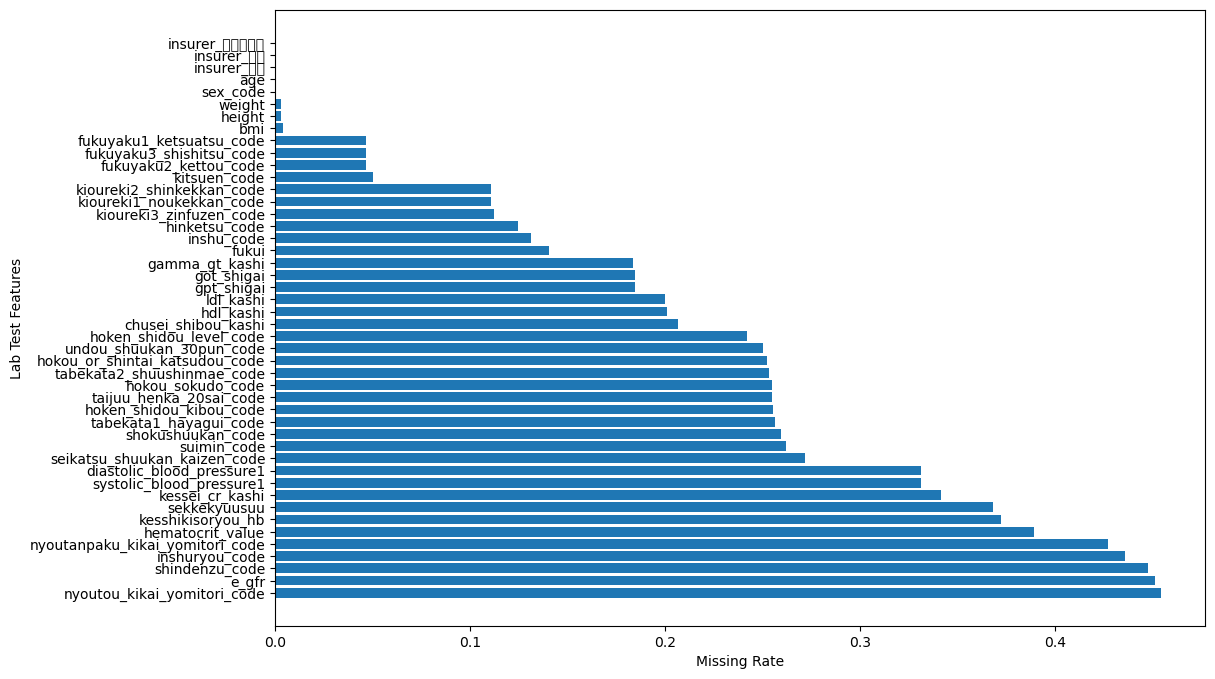

In [ ]:
plt.figure(figsize=(12, 8))
f = lambda x: re.match(r"^[A-Z][0-9]{2}$|^999$|(0|^[0-9]{7}).0$|\d.",str(x))==None
labtest_col = df.columns[list(map(f,df.columns))]
df_temp = X_calib[labtest_col]
df_temp = df_temp.isna().mean().sort_values(ascending=False).reset_index()
plt.barh(df_temp["index"], df_temp[0])
plt.xlabel("Missing Rate")
plt.ylabel("Lab Test Features")

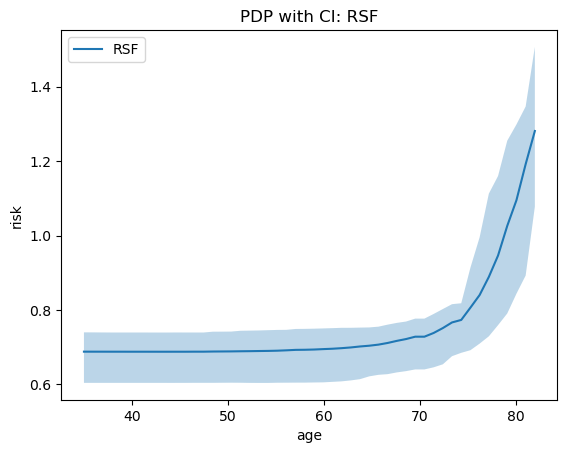

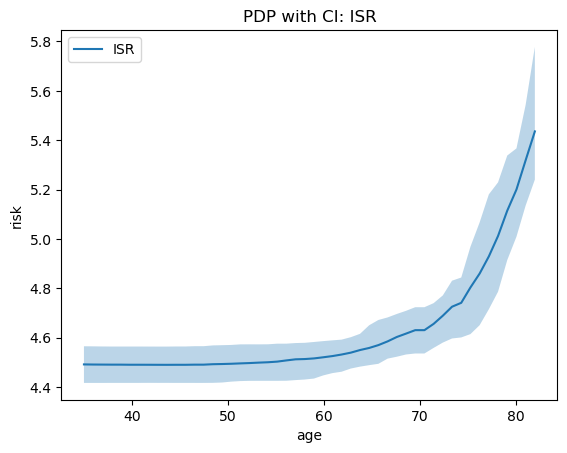

In [13]:
all_results = {
    "RSF": [],
    "ISR": [],
   # "ISR_DYK": []
}
time_grid = np.arange(1, 72)

feature = "age"

grid_values = np.linspace(
    X_eval[feature].quantile(0.05),
    X_eval[feature].quantile(0.95),
    50  # ← grid_resolution
)

for i in range(n_rep):

    model_path = f"/data/chida/desc/S720-S722/Manuscript/ratio_50/Model_{i}.pkl"
    if not os.path.exists(model_path):
        continue

    with open(model_path, "rb") as f:
        model = pickle.load(f)

    #model.__class__ = RSF_Calibrated  

    pdp = compute_pdp_all(
        model,
        X_sub,
        feature="age",
        grid_values=grid_values
    )

    for k in all_results:
        all_results[k].append(pdp[k])


for k in all_results:
    all_results[k] = np.array(all_results[k])
    # shape: (n_bootstrap, n_grid)

summary = {}

for k in all_results:

    summary[k] = {
        "mean": all_results[k].mean(axis=0),
        "lower": np.percentile(all_results[k], 2.5, axis=0),
        "upper": np.percentile(all_results[k], 97.5, axis=0)
    }

import matplotlib.pyplot as plt

for k in summary:

    plt.figure()

    plt.plot(grid_values, summary[k]["mean"], label=k)

    plt.fill_between(
        grid_values,
        summary[k]["lower"],
        summary[k]["upper"],
        alpha=0.3
    )

    plt.title(f"PDP with CI: {k}")
    plt.xlabel("age")
    plt.ylabel("risk")
    plt.legend()

    plt.show()
